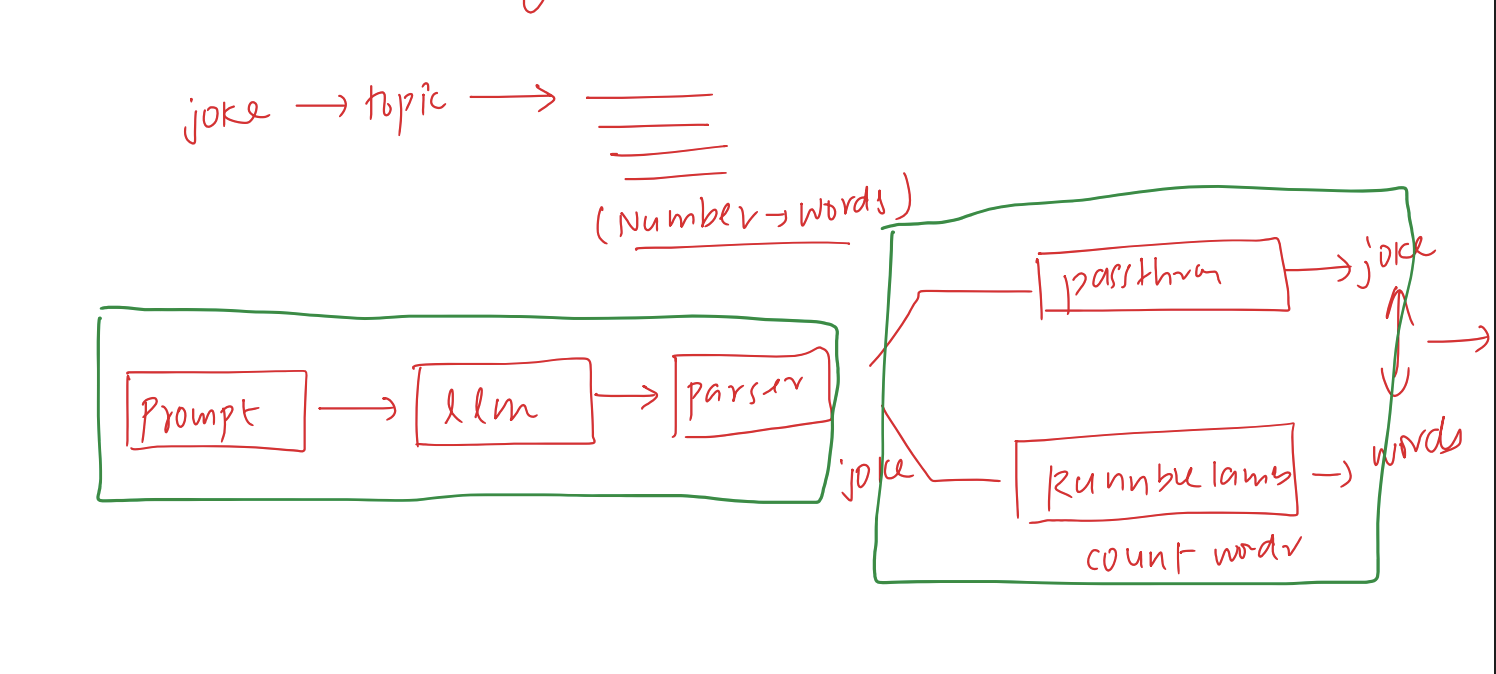

### RunnableLambda
- Purpose: To convert any arbitrary Python function into a Runnable.
This allows you to add custom logic (like text preprocessing,
calculations, API calls) directly into your LangChain pipeline.
- When to Use: Whenever you need to perform a custom operation that
isn't covered by a pre-built LangChain component.

### Code Example (Scenario: Generate a joke and also count its words):

### define models and parser

In [1]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from dotenv import load_dotenv
import os

# Load environment variables
load_dotenv()

api_key = os.getenv("Hugging_face_api_token")

# Create LLM endpoint
llm = HuggingFaceEndpoint(
    # repo_id="TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    repo_id="mistralai/Mistral-7B-Instruct-v0.2",
    task="text-generation",
    huggingfacehub_api_token=api_key,
)

# Wrap with chat interface
model1 = ChatHuggingFace(llm=llm)
model2=ChatHuggingFace(llm=llm)

In [3]:
from langchain_core.output_parsers import StrOutputParser
parser=StrOutputParser()

### define prompt templates

In [2]:
from langchain_core.prompts import PromptTemplate
#generate joke template
joke_gen_prompt=PromptTemplate(
    template="Tell a joke about {topic}",
    input_variables=["topic"]
)

### create chain and invoke

In [4]:
from langchain_core.runnables import RunnableLambda,RunnableParallel,RunnablePassthrough
# custom function to count words
def word_counter(text:str)->int:
    return len(text.split())

#Convert that function to a runnable
word_count_runnable=RunnableLambda(word_counter)

#chain 1:Generate joke
joke_gen_chain=joke_gen_prompt|model1|parser

#Parallel Chain:One branch passes the joke,the other branch count its words
parallel_chain=RunnableParallel({
    "return_joke":RunnablePassthrough(),
    "return_word_count":word_count_runnable
}
)

#merging this two chain to get final chain

final_chain=joke_gen_chain|parallel_chain



In [5]:
result=final_chain.invoke({"topic":"AI"})

In [6]:
print(result)

{'return_joke': 'Why don\'t computers take their hats off during the national anthem?\n\nBecause they don\'t want to risk a \'Byte\' of disrespect to their \'Processor\'! (A play on the phrases "take off your hat" and "show respect to the processor" in relation to computers and bytes)', 'return_word_count': 45}


In [7]:
type(result)

dict

In [8]:
result["return_joke"]

'Why don\'t computers take their hats off during the national anthem?\n\nBecause they don\'t want to risk a \'Byte\' of disrespect to their \'Processor\'! (A play on the phrases "take off your hat" and "show respect to the processor" in relation to computers and bytes)'

In [9]:
result["return_word_count"]

45